# 

# Supplement B: Scoping Review Results

In [ ]:
targets::tar_source('R')



Attaching package: 'janitor'

The following objects are masked from 'package:stats':

    chisq.test, fisher.test

Linking to GEOS 3.13.0, GDAL 3.10.0, PROJ 9.5.0; sf_use_s2() is TRUE


Attaching package: 'testthat'

The following object is masked from 'package:tarchetypes':

    matches

The following object is masked from 'package:targets':

    matches

## Results

### PRISMA

    3870 references imported for screening as 3870 studies
      128 duplicates identified manually
      799 duplicates identified by Covidence
    2943 studies screened against title and abstract
      2527 studies excluded
    416 studies assessed for full-text eligibility
      262 studies excluded
        171  Does not discuss dyadic metric
        86  Metric not applicable to spatiotemporal data
        2  Book chapter
        2  Full text not in English
        1  Thesis
      0 studies ongoing
      0 studies awaiting classification
    154 studies included

### Code availability

In [ ]:
count_code_avail[, .N, V1][, .(
  `Code availability` = V1,
  N = paste_n_percent(N)
)] |> tt()


Code availability,N
No,107 (82%)
Yes,24 (18%)


### Programming language / GUI program

Out of 131 articles, 45 did not list a programming language or GUI program. Of the 86 that did, 20 articles listed more than one programming language or GUI program, therefore the total count below will be greater than the number of articles.

In [ ]:
count_prog <- count_prog_lang[!is.na(V1), .N, V1]

count_prog[order(-N), 
           .(`Programming language / GUI software` = V1, 
             N = paste_n_percent(N))] |> 
  tt()


Programming language / GUI software,N
R,51 (44.35%)
MATLAB,13 (11.30%)
R,8 (6.96%)
Python,4 (3.48%)
CUDA,4 (3.48%)
NetLogo,2 (1.74%)
MATLAB,2 (1.74%)
Ucinet,2 (1.74%)
C++,2 (1.74%)
Python,2 (1.74%)


### Software packages

Out of 130 articles, 105 did not list a software package. Of the 25 that did, 12 articles listed more than one software package , therefore the total count below will be greater than the number of articles.

In [ ]:
count_soft_na_rm <- count_software[!is.na(V1), .N, V1]

count_soft_na_rm[order(-N),
           .(`Software package` = V1,
             N = paste_n_percent(N))] |>
  tt()


Software package,N
wildlifeDI,6 (12.5%)
wildlifeDI,3 (6.2%)
adehabitat,2 (4.2%)
moveVis,2 (4.2%)
ctmm,2 (4.2%)
CircStats,2 (4.2%)
geosphere,2 (4.2%)
corrMove,2 (4.2%)
adehabitatHR,2 (4.2%)
numpy,2 (4.2%)


#### Software packages metadata

In [ ]:
software_meta |> 
  tt()


package,N,description,on_CRAN,archive_date,months_since_updated,metrics
wildlifeDI,9,"dyadic interaction metrics, contact analysis",TRUE,NA,3,Ca; Cr; DI; Don; HAI; IAB; Lixn; Prox
swaRm,1,processing individual and collective movement data,TRUE,NA,3,angular acceleration; ang speed; centroid; convex hull; dist to centroid; heading; linear acc; speed; dist; NN; NN dist; NSD; dist matrix; polarization order; sphericity; stretch
corrMove,2,correlated movements between individuals,FALSE,NA,84,diffusive movement correlation; drift movement correlation; overall component movement correlation
adehabitatLT,1,analysis of animal movements,TRUE,NA,10,NA
adehabitatHR,2,home range estimation,TRUE,NA,10,NA
adehabitat,2,analysis of habitat selection,FALSE,2018-04-10,84,NA
moveVis,2,animating movement trajectories,FALSE,2023-07-11,24,NA
sf,0,spatial data,TRUE,NA,0,NA
ctmm,2,continuous time movement modeling,TRUE,NA,0,NA
geosphere,2,spherical trigonometry,TRUE,NA,6,NA


### Metrics

In [ ]:
count_met <- count_metric[, .(N = uniqueN(covidence_number)), V1]

count_met[order(-N, V1), 
          .(`Metric` = V1, 
            N = paste_n_percent(N, count_metric[, uniqueN(covidence_number)]))] |> 
  tt()


Metric,N
interindividual distance,32 (25.00%)
interindividual distance,21 (16.41%)
nearest neighbour distance,14 (10.94%)
speed,14 (10.94%)
directional correlation delay,13 (10.16%)
fission fusion,12 (9.38%)
position within group,10 (7.81%)
distance to group centroid,9 (7.03%)
zones,8 (6.25%)
direction,7 (5.47%)


### Temporal

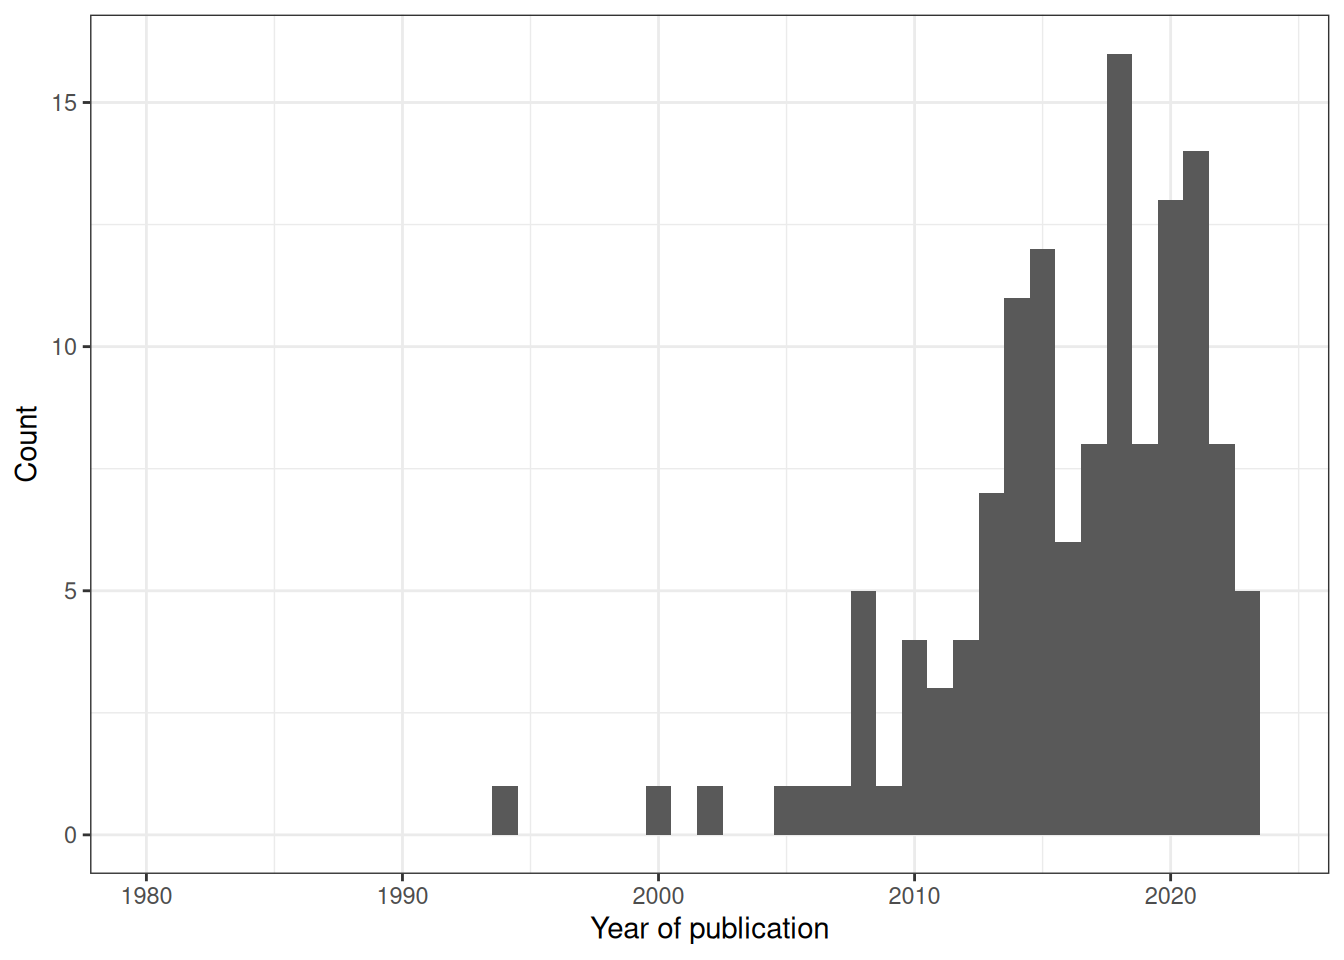

In [ ]:
ggplot(review) + 
  geom_histogram(aes(yr), binwidth = 1) + 
  labs(x = 'Year of publication', y = 'Count') + 
  coord_cartesian(xlim = c(1980, 2024)) +
  theme_bw()


### Geographic

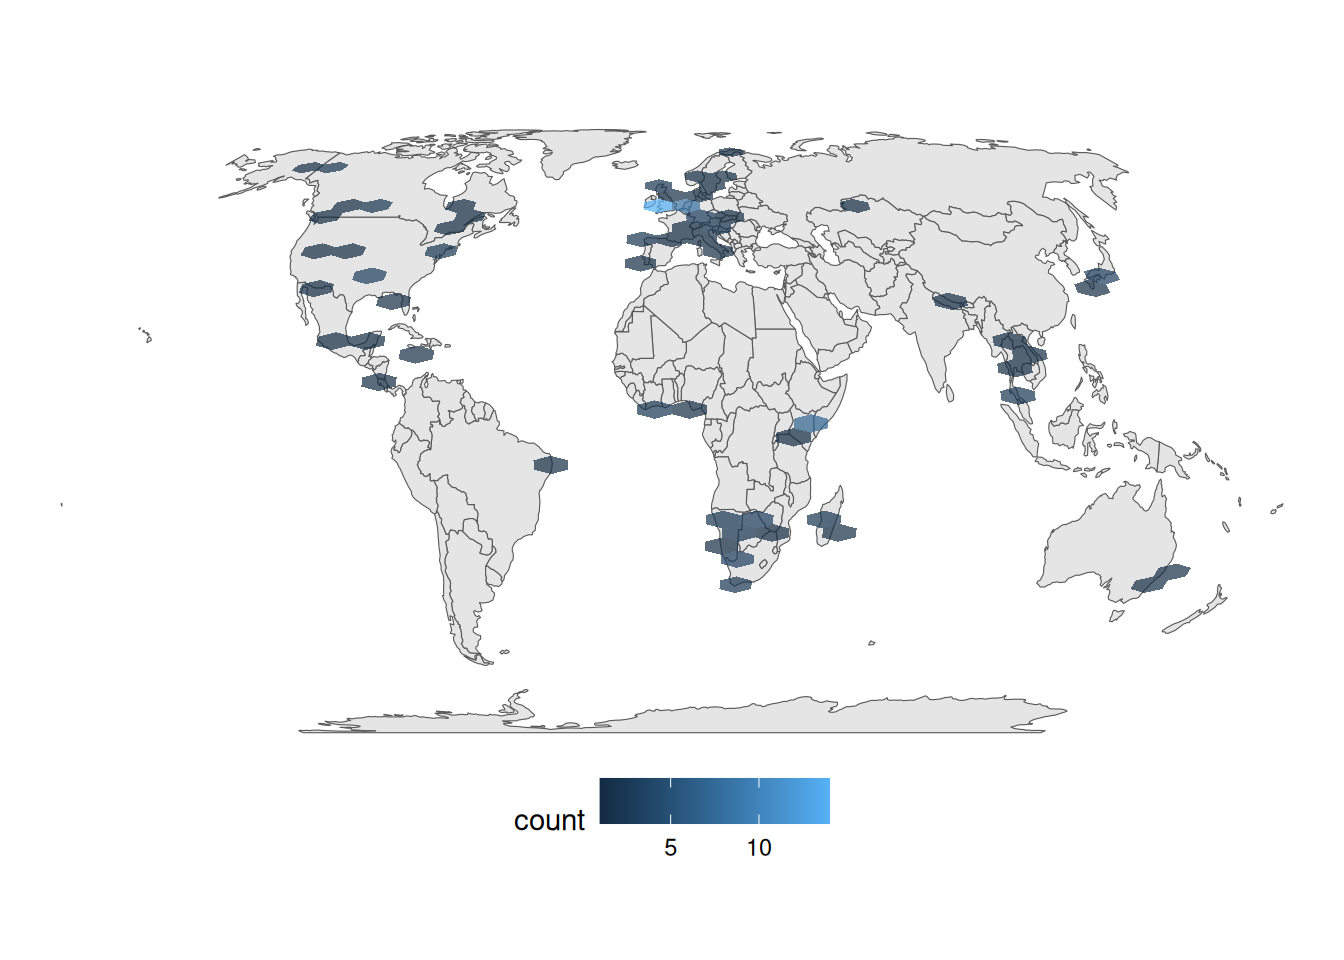

In [ ]:
countries <- ne_countries()

crs <- 8857

ggplot() + 
  geom_sf(data = countries) + 
  geom_hex(aes(long, lat), alpha = 0.7, data = geocoded[!is.na(long)]) + 
  coord_sf(crs = crs, default_crs = 4326) + 
  theme_void() + 
  theme(legend.position = 'bottom')


### Species

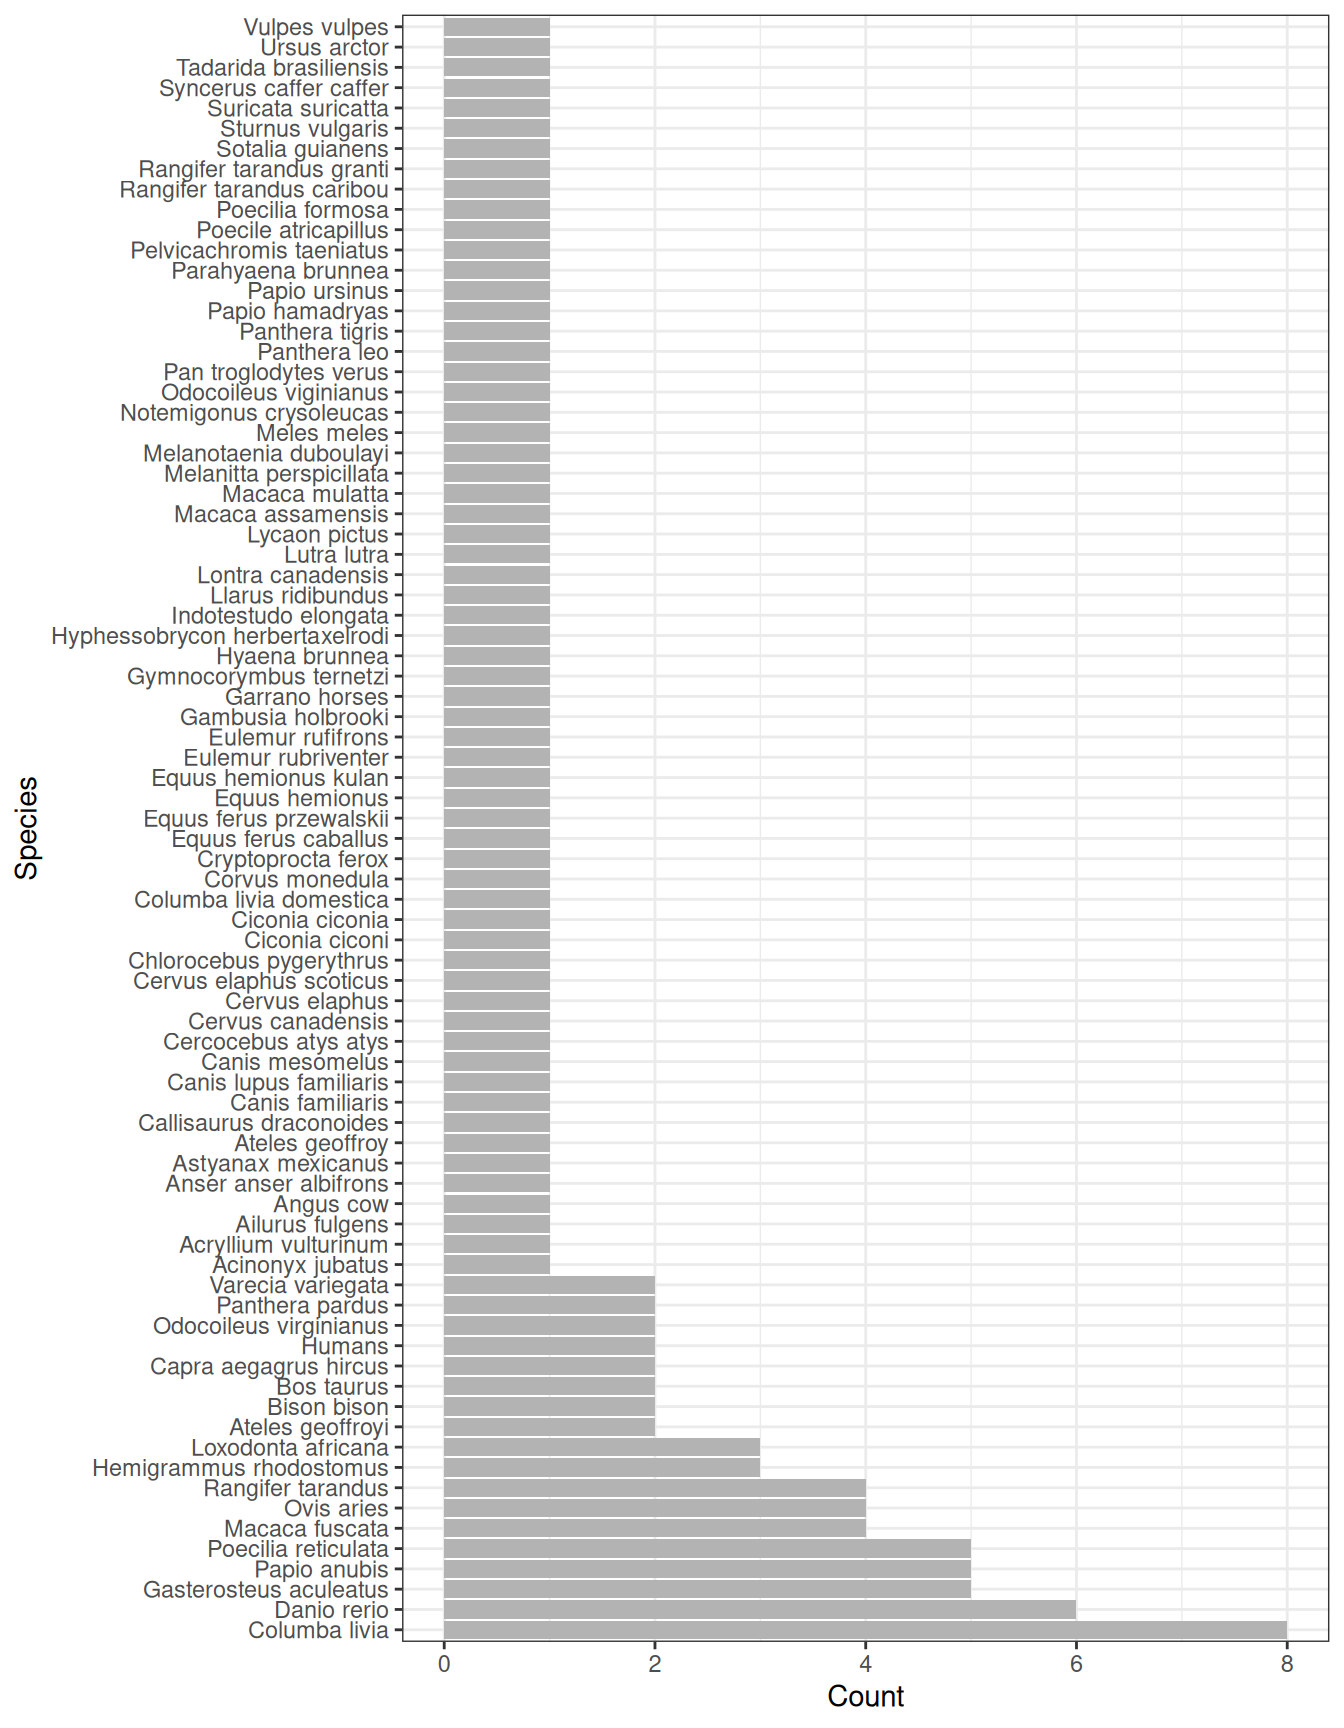

In [ ]:
ggplot(taxized) + 
  geom_bar(aes(y = fct_infreq(species)),
           fill = 'grey70',
           linewidth = 0.1) +
  theme_bw() + 
  labs(x = 'Count', y = 'Species')


### Fission fusion

In [ ]:
review[grepl('fission', metric_agg), .(study_id, definitions_of_leader_initiator_etc)] |> 
  tt()


study_id,definitions_of_leader_initiator_etc
Baden 2016,NA
Aguilar-Melo 2018,fission when gte 1 were not observed with a group for 2 consecutive scans; fusion when gte 1 who were previously not observed with group are observed with group for 2 consecutive scans
Barocas 2016,fission and fusion defined as joining and leaving group in subsequent observations
Haydon 2008,fusion where solitary to grouped and fission where grouped to solitary
Fortin 2009,group/fusion when within 100 m; fission when two or more consecutive locations separated by > 100 m
Body 2015,fusion gte 2 groups merging into one; fission one group splitting into gte 2
DellaLibera 2023,"define a fission and fusion event if one or more individuals left or joined the group, respectively. in the rare cases of missing data, missing individuals are not considered as having changed group membership, and individual ‘disappearances’ and ‘reappearances’ in the dataset are not considered as fission–fusion events"
Wielgus 2020,group where simultaneously within 1 km or >= 1 km for <= 2 hr; fusion where together then different by one time step; fission reverse
Nishikawa 2014,converged when IID less than 20 m; separated when IID greater than 20 m; converged and separated synonymous with fission fusion
Krueger 2014,NA
